In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the Pima Diabetes Dataset

diabetes_data = pd.read_csv(
    "pima_diabetes.csv",
    header=None,
    names=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"
    ]
)

print("Diabetes dataset loaded successfully!")
print("\nDataset Sample:")
print(diabetes_data.head())

Diabetes dataset loaded successfully!

Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


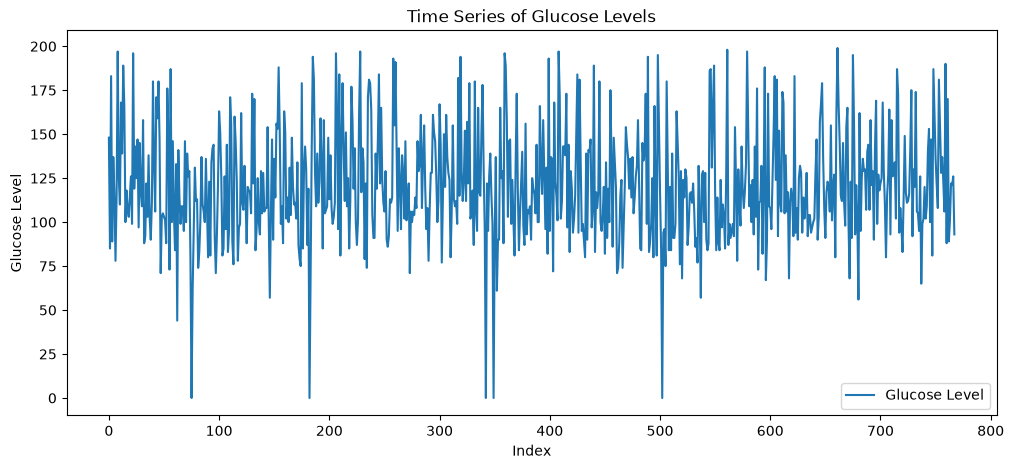

In [4]:
# Plot Time Series of Glucose Levels

plt.figure(figsize=(12, 5))

plt.plot(
    diabetes_data["Glucose"],
    label="Glucose Level"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.legend()
plt.show()

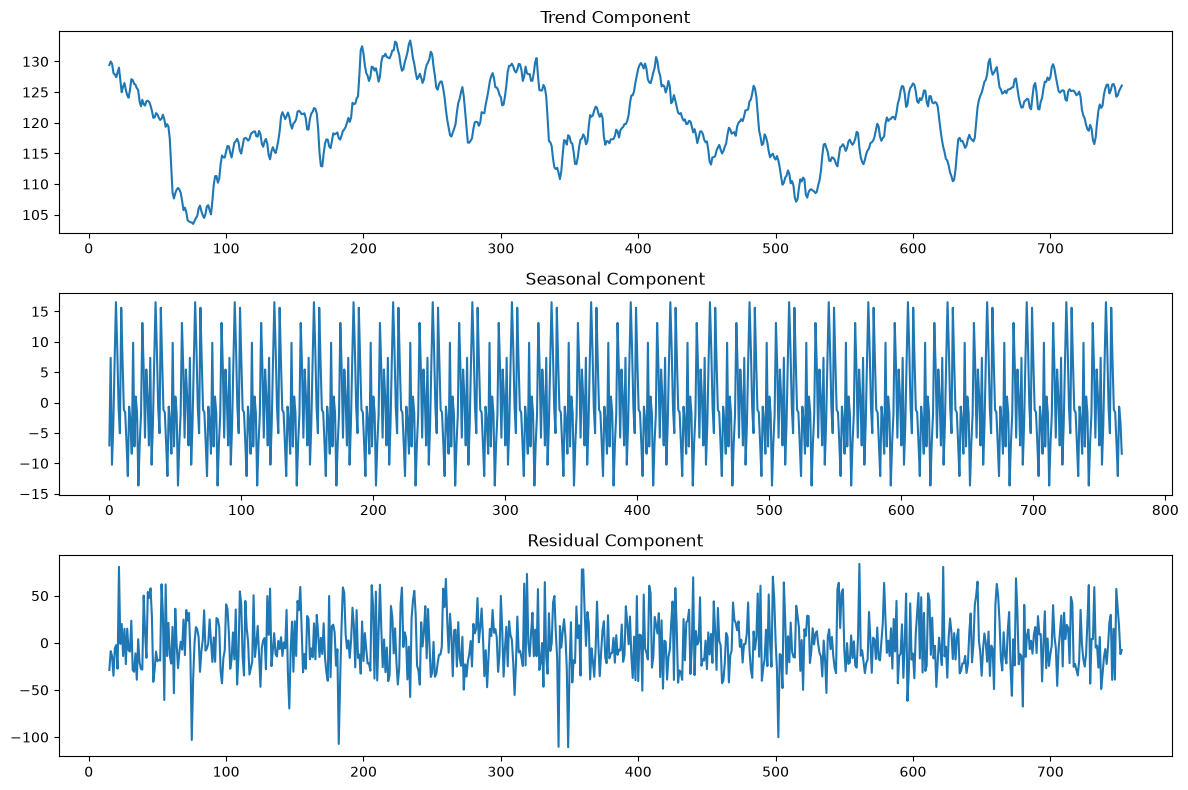

In [5]:
# Decompose Time Series into Trend, Seasonality, and Residuals

decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=30
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

decomposition.trend.plot(
    ax=axes[0],
    title="Trend Component"
)

decomposition.seasonal.plot(
    ax=axes[1],
    title="Seasonal Component"
)

decomposition.resid.plot(
    ax=axes[2],
    title="Residual Component"
)

plt.tight_layout()
plt.show()

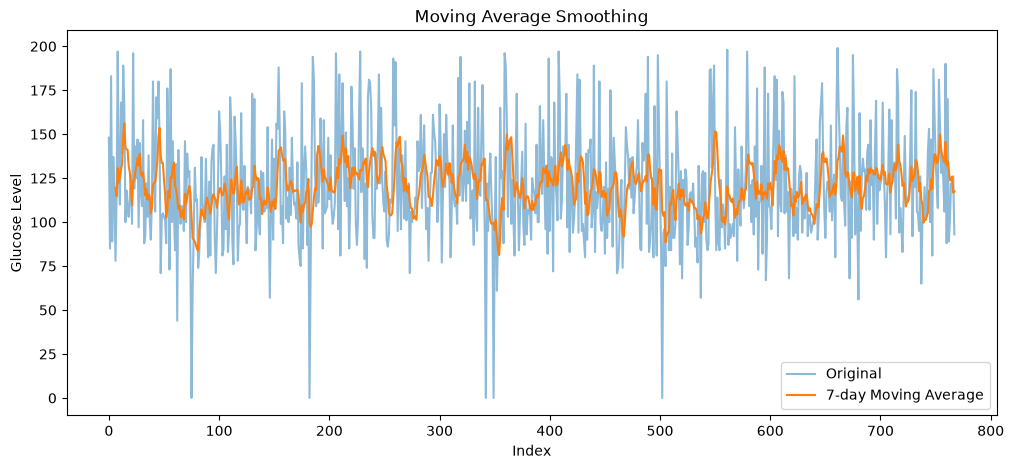

In [6]:
# Apply Moving Average for Smoothing

diabetes_data["Glucose_MA"] = diabetes_data["Glucose"].rolling(window=7).mean()

plt.figure(figsize=(12, 5))

plt.plot(
    diabetes_data["Glucose"],
    label="Original",
    alpha=0.5
)

plt.plot(
    diabetes_data["Glucose_MA"],
    label="7-day Moving Average"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Moving Average Smoothing")
plt.legend()
plt.show()

In [7]:
# Build ARIMA Model for Forecasting

train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

model = ARIMA(train, order=(5, 1, 0))

fitted_model = model.fit()

print("ARIMA model fitted successfully!")
print("Training samples:", len(train))
print("Testing samples:", len(test))

ARIMA model fitted successfully!
Training samples: 614
Testing samples: 154


In [8]:
# Forecast Future Glucose Levels

forecast = fitted_model.forecast(steps=len(test))

print("Forecast generated successfully!")
print("\nFirst 10 Forecasted Values:")
print(forecast.head(10))

Forecast generated successfully!

First 10 Forecasted Values:
614    135.115764
615    128.020159
616    132.754874
617    144.113482
618    136.702538
619    130.728254
620    134.114918
621    133.268319
622    135.101923
623    136.271992
Name: predicted_mean, dtype: float64


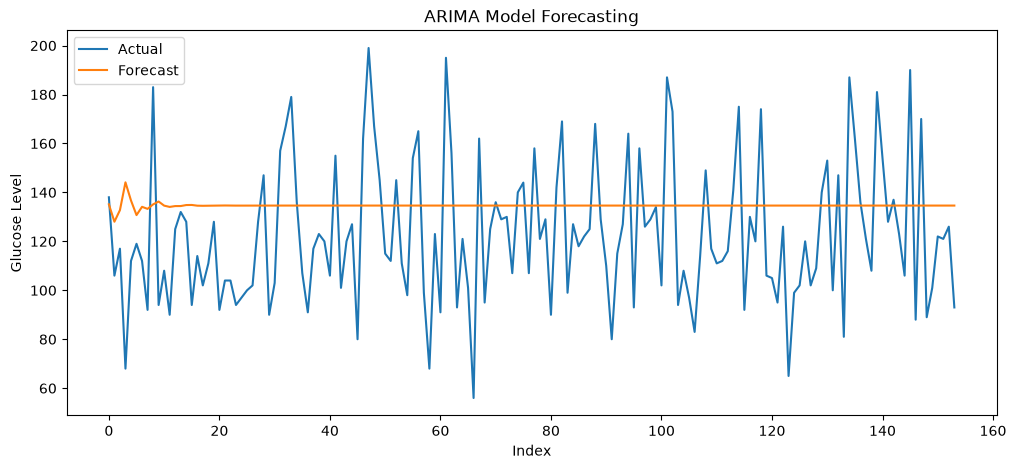

In [9]:
# Plot Forecast vs Actual Data

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(test)),
    test,
    label="Actual"
)

plt.plot(
    range(len(test)),
    forecast,
    label="Forecast"
)

plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("ARIMA Model Forecasting")
plt.legend()
plt.show()

In [10]:
print("RESULT:")
print(
    "The Time Series Analysis identifies trends and seasonal patterns "
    "in glucose levels. Moving Average smoothing helps identify the "
    "underlying trend, while the ARIMA model is used to forecast "
    "future glucose values."
)

RESULT:
The Time Series Analysis identifies trends and seasonal patterns in glucose levels. Moving Average smoothing helps identify the underlying trend, while the ARIMA model is used to forecast future glucose values.
